# Análise por Elementos Finitos — Treliça Espacial de 25 Barras

Tradução em Python dos scripts MATLAB da pasta `PNL`
(`REC_2022_trelica_3D.m`, `DataMEF3D_25barDisc.m`, `trelica_FEA.m`, `massa_trelica_3D.m`,
`tensoes_maximas.m`, `TrussPlot3D.m`, `gplot3.m`).

Modela o clássico benchmark de otimização estrutural da **treliça espacial de 25 barras**
(10 nós, 25 elementos de barra, apoiados nos 4 nós da base) pelo **Método dos Elementos
Finitos** (método da rigidez direta para elementos de treliça 3D): monta a matriz de
rigidez global a partir dos cossenos diretores e área de cada barra, resolve o sistema
linear de equilíbrio estático para os deslocamentos nodais, e recupera a tensão axial em
cada barra.

O script original (`REC_2022_trelica_3D.m`) executa apenas a análise com diâmetros
uniformes ($d_i=2$ para todas as barras) e plota a estrutura — o trecho de otimização
(`fmincon`) é deixado como exercício em aberto no script original (comentário
`% Escreva o otimizador aqui`), e assim é mantido aqui: apenas a análise estrutural e o
cálculo de massa/tensões (usados como objetivo/restrição de uma futura otimização) são
implementados.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (habilita projection='3d')

## Dados de entrada (`DataMEF3D_25barDisc.m`)

Coordenadas dos 10 nós (em polegadas, escaladas por 12), incidência das 25 barras,
propriedades do material (aço, $E=3\times10^7$ psi), condições de contorno (4 nós da base
totalmente engastados) e carregamento (duas forças horizontais de $60\,000$ lb aplicadas
no topo).

In [2]:
# coord = [Xno, Yno, Zno]
coord = np.array([
    [-1.5, 0.0, 8.0],
    [1.5, 0.0, 8.0],
    [-1.5, 1.5, 4.0],
    [1.5, 1.5, 4.0],
    [1.5, -1.5, 4.0],
    [-1.5, -1.5, 4.0],
    [-4.0, 4.0, 0.0],
    [4.0, 4.0, 0.0],
    [4.0, -4.0, 0.0],
    [-4.0, -4.0, 0.0],
]) * 12

# inci = [elemento, prop.mat., prop.geom., nó i, nó j]  (índices de nó em base 1, como no MATLAB)
inci = np.array([
    [1, 1, 1, 1, 2], [2, 1, 1, 1, 4], [3, 1, 1, 2, 3], [4, 1, 1, 1, 5], [5, 1, 1, 2, 6],
    [6, 1, 1, 2, 4], [7, 1, 1, 2, 5], [8, 1, 1, 1, 3], [9, 1, 1, 1, 6], [10, 1, 1, 6, 3],
    [11, 1, 1, 5, 4], [12, 1, 1, 3, 4], [13, 1, 1, 6, 5], [14, 1, 1, 3, 10], [15, 1, 1, 6, 7],
    [16, 1, 1, 4, 9], [17, 1, 1, 5, 8], [18, 1, 1, 4, 7], [19, 1, 1, 3, 8], [20, 1, 1, 5, 10],
    [21, 1, 1, 6, 9], [22, 1, 1, 6, 10], [23, 1, 1, 3, 7], [24, 1, 1, 4, 8], [25, 1, 1, 5, 9],
])

# tmat = [E, Poisson, rho]
tmat = np.array([3e7, 0.3, 7.3e-4])

# tgeo = [Área (m^2), Momento de inércia (m^4)]  (não usado por trelica_FEA, mantido por fidelidade)
tgeo = np.array([np.pi, 0.0001])

# cont = [nó, GDL(U=1,V=2,W=3)] -- 4 nós da base totalmente engastados
cont = np.array([
    [7, 1], [7, 2], [7, 3],
    [8, 1], [8, 2], [8, 3],
    [9, 1], [9, 2], [9, 3],
    [10, 1], [10, 2], [10, 3],
])

# loads = [nó, GDL, valor]
loads = np.array([
    [1, 2, 60e3],
    [2, 2, 60e3],
])

sigma_max = 37e3 / 1.5

## Análise por elementos finitos (`trelica_FEA.m`)

Para um vetor `x` de **diâmetros** de barra (25 valores), monta a matriz de rigidez global
$K_g$ por superposição das matrizes de rigidez elementares (elemento de barra 3D, área
$A_i=\pi x_i^2/4$), resolve $K_g U = F$ para os deslocamentos nodais livres, e recupera a
tensão axial em cada barra a partir dos deslocamentos e dos cossenos diretores.

In [3]:
def trelica_FEA(x):
    """x: vetor de diâmetros das 25 barras. Retorna (U, Tens)."""
    nnos = coord.shape[0]
    nel = inci.shape[0]
    ngdl = 3

    id_ = np.ones((ngdl, nnos), dtype=int)
    for no, gdl in cont:
        id_[gdl - 1, no - 1] = 0

    neq = 0
    for i in range(nnos):
        for j in range(ngdl):
            if id_[j, i] == 1:
                neq += 1
                id_[j, i] = neq

    F = np.zeros(neq)
    Kg = np.zeros((neq, neq))

    for no, gdl, valor in loads:
        no, gdl = int(no), int(gdl)
        if id_[gdl - 1, no - 1] != 0:
            F[id_[gdl - 1, no - 1] - 1] += valor

    E = tmat[0]
    for i in range(nel):
        noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
        x1, y1, z1 = coord[noi]
        x2, y2, z2 = coord[noj]
        Le = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)
        l, m, n = (x2 - x1) / Le, (y2 - y1) / Le, (z2 - z1) / Le

        matL = np.array([[l, m, n, 0, 0, 0], [0, 0, 0, l, m, n]])
        A = np.pi * x[i] ** 2 / 4
        ke = (E * A / Le) * matL.T @ np.array([[1, -1], [-1, 1]]) @ matL

        loc = [id_[0, noi], id_[1, noi], id_[2, noi], id_[0, noj], id_[1, noj], id_[2, noj]]
        for il in range(6):
            ilg = loc[il]
            if ilg != 0:
                for ic in range(6):
                    icg = loc[ic]
                    if icg != 0:
                        Kg[ilg - 1, icg - 1] += ke[il, ic]

    X = np.linalg.solve(Kg, F)

    U = np.zeros((nnos, 3))
    for i in range(nnos):
        for j in range(3):
            if id_[j, i] != 0:
                U[i, j] = X[id_[j, i] - 1]

    Tens = np.zeros(nel)
    for i in range(nel):
        noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
        vet = np.concatenate([U[noi], U[noj]])

        x1, y1, z1 = coord[noi]
        x2, y2, z2 = coord[noj]
        Le = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)
        l, m, n = (x2 - x1) / Le, (y2 - y1) / Le, (z2 - z1) / Le

        matL = np.array([[l, m, n, 0, 0, 0], [0, 0, 0, l, m, n]])
        Tens[i] = E / Le * np.array([-1, 1]) @ matL @ vet

    return U, Tens

## Massa e restrição de tensão (`massa_trelica_3D.m`, `tensoes_maximas.m`)

Estas duas funções seriam, respectivamente, a função objetivo e a restrição de uma futura
otimização de dimensionamento (minimizar massa sujeita a $|\text{tensão}|\le\sigma_{max}$),
mas são apenas definidas e avaliadas aqui, como no script original.

In [4]:
def massa_trelica_3D(x):
    """Massa total da treliça para o vetor de diâmetros x."""
    nel = len(x)
    wval = 0.0
    for i in range(nel):
        noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
        x1, y1, z1 = coord[noi]
        x2, y2, z2 = coord[noj]
        Le = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)
        A = np.pi * x[i] ** 2 / 4
        rho = tmat[2]
        wval += rho * A * Le
    return wval


def tensoes_maximas(x):
    """c(x) <= 0 <=> |tensão| <= sigma_max, para cada barra."""
    _, Tens = trelica_FEA(x)
    c = np.abs(Tens) - sigma_max
    return c, []

## Visualização 3D da treliça (`TrussPlot3D.m`, `gplot3.m`)

Plota a estrutura indeformada (com marcação dos apoios engastados) e a estrutura
deformada, com deslocamentos amplificados por um fator de escala. (Os símbolos triangulares
de apoio do MATLAB são aqui simplificados para marcadores 3D — a análise estrutural em si é
reproduzida de forma exata.)

In [5]:
def truss_plot_3d(U, Tens, fator):
    nnos = coord.shape[0]
    nel = inci.shape[0]

    coordX = coord + fator * U        # coordenadas com fator de escala (deformada amplificada)
    coord_r = coord + U               # coordenadas reais deformadas

    imax = np.argmax(Tens)
    nos_apoio = set(cont[:, 0].astype(int) - 1)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    for i in range(nel):
        noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
        ax.plot(*zip(coord[noi], coord[noj]), 'o-', color='b')
        mid = (coord[noi] + coord[noj]) / 2
        ax.text(*mid, str(i + 1), fontsize=7, ha='center',
                bbox={'facecolor': (.9, .9, .9), 'edgecolor': 'black'})
    for i in range(nnos):
        ax.text(*coord[i], str(i + 1), fontsize=11, ha='center', va='bottom')
    for i in nos_apoio:
        ax.scatter(*coord[i], color='k', marker='^', s=120)
    ax.set_title('Treliça indeformada (▲ = apoio engastado)')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    plt.show()

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    for i in range(nel):
        noi, noj = int(inci[i, 3]) - 1, int(inci[i, 4]) - 1
        cor = 'r' if i == imax else 'k'
        ax.plot(*zip(coordX[noi], coordX[noj]), '-', color=cor, linewidth=1.5)
    for i in range(nnos):
        ax.scatter(*coordX[i], color='k')
    for i in nos_apoio:
        ax.scatter(*coord_r[i], color='k', marker='^', s=120)
    ax.set_title(f'Treliça deformada (escala={fator}), barra mais tensionada em vermelho')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    plt.show()

## Execução (`REC_2022_trelica_3D.m`)

Análise de exemplo com diâmetro uniforme $d_i=2$ (todas as barras) e plot da estrutura com
fator de escala unitário.

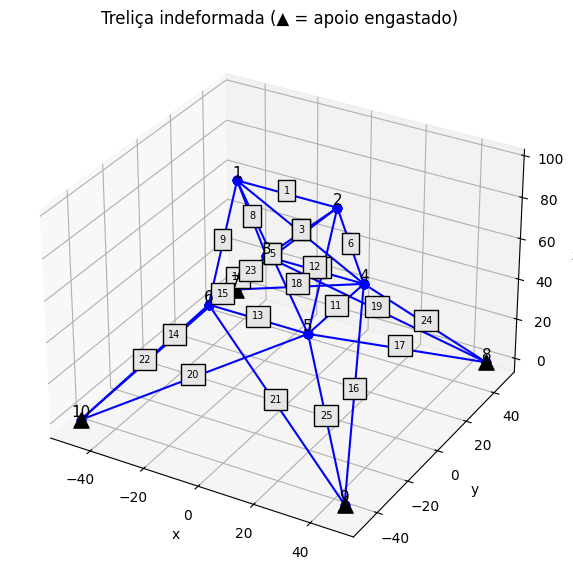

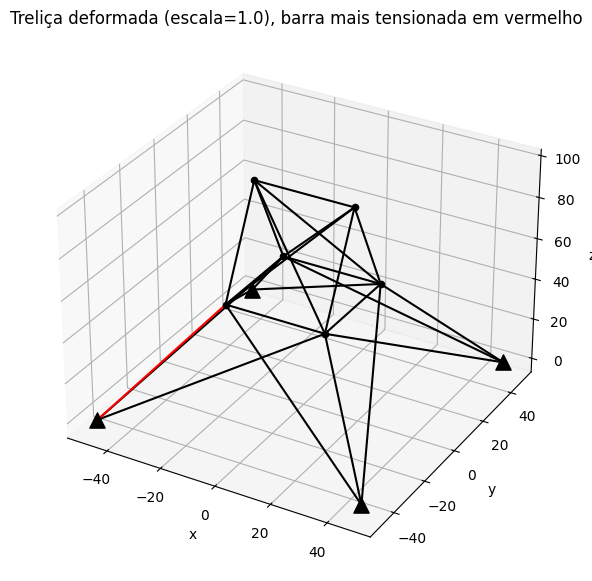

Massa = 3.640620094177754
Tensão máxima (abs) = 21588.472123906136  sigma_max = 24666.666666666668


In [6]:
x = np.ones(25) * 2
U, Tens = trelica_FEA(x)

escala = 1e0
truss_plot_3d(U, Tens, escala)

print('Massa =', massa_trelica_3D(x))
print('Tensão máxima (abs) =', np.abs(Tens).max(), ' sigma_max =', sigma_max)

# Escreva o otimizador aqui, com fmincon (equivalente scipy.optimize.minimize(method='SLSQP'))
# ...
# ...